In [35]:
from mads_datasets.base import BaseDatastreamer
from mltrainer.preprocessors import BasePreprocessor
from pathlib import Path
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torch import nn
import torch

from src import datasets, metrics

In [36]:
import tomllib

datadir = Path('../data')
configfile = Path("config.toml")

with configfile.open('rb') as f:
    config = tomllib.load(f)
print(config)

{'ptb': 'heart', 'arrhythmia': 'heart_big'}


In [37]:
trainfile = datadir / (config['arrhythmia'] + '_train.parq')
testfile = datadir / (config['arrhythmia'] + '_test.parq')
trainfile, testfile

(PosixPath('../data/heart_big_train.parq'),
 PosixPath('../data/heart_big_test.parq'))

In [38]:
shape = (16, 12)
traindataset = datasets.HeartDataset2D(trainfile, target="target", shape=shape)
testdataset = datasets.HeartDataset2D(testfile, target="target", shape=shape)
traindataset, testdataset

(Heartdataset2D (#87554), Heartdataset2D (#21892))

In [39]:
trainstreamer = BaseDatastreamer(
    traindataset, 
    preprocessor = BasePreprocessor(), 
    batchsize=32
    )

teststreamer = BaseDatastreamer(
    testdataset, 
    preprocessor = BasePreprocessor(), 
    batchsize=32
    )

len(trainstreamer), len(teststreamer)

(2736, 684)

In [40]:
trainloader = trainstreamer.stream()

x, y = next(iter(trainloader))

print(x.shape)
print(y.shape)

torch.Size([32, 1, 16, 12])
torch.Size([32])


In [41]:
from mltrainer.imagemodels import CNNConfig

In [42]:
class CNN2D(nn.Module):
    def __init__(
        self,
        features: int = 1,
        num_classes: int = 5,
        kernel_size: int = 3,
        filters: int = 16,
        matrixshape: tuple = (16, 12),
    ) -> None:
        super().__init__()

        self.convolutions = nn.Sequential(
            nn.Conv2d(
                in_channels=features,
                out_channels=filters,
                kernel_size=kernel_size,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        flatten_size = (
            filters
            * (matrixshape[0] // 2)
            * (matrixshape[1] // 2)
        )

        self.dense = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.convolutions(x)
        logits = self.dense(x)
        return logits

In [ ]:
model = CNN2D(
    num_classes=5,
    filters=16,
    matrixshape=(16, 12),
)

x, y = next(iter(trainloader))

model.eval()

with torch.no_grad():
    output = model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)
print("Target shape:", y.shape)

Input shape: torch.Size([32, 1, 16, 12])
Output shape: torch.Size([32, 5])
Target shape: torch.Size([32])


In [44]:
f1micro = metrics.F1Score(average="micro")
f1macro = metrics.F1Score(average="macro")
precision = metrics.Precision("micro")
recall = metrics.Recall("macro")
accuracy = metrics.Accuracy()

metrics_list = [
    f1micro,
    f1macro,
    precision,
    recall,
    accuracy,
]

In [45]:
from mltrainer import ReportTypes, Trainer, TrainerSettings

model = CNN2D(
    num_classes=5,
    filters=16,
    matrixshape=(16, 12),
)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam

train_steps = len(trainstreamer) // 5
valid_steps = len(teststreamer) // 5

settings = TrainerSettings(
    epochs=3,
    metrics=[
        accuracy,
        f1micro,
        f1macro,
        precision,
        recall,
    ],
    logdir="logs/baseline_2d",
    train_steps=train_steps,
    valid_steps=valid_steps,
    reporttypes=[ReportTypes.TENSORBOARD],
    earlystop_kwargs=None,
)

trainer = Trainer(
    model=model,
    settings=settings,
    loss_fn=loss_fn,
    optimizer=optimizer,
    traindataloader=trainstreamer.stream(),
    validdataloader=teststreamer.stream(),
    scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau,
)

trainer.loop()

2026-07-15 09:46:54.148 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/baseline_2d/20260715-094654
100%|██████████| 547/547 [00:03<00:00, 169.44it/s]
2026-07-15 09:46:59.719 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.4619 test 0.3473 metric ['0.9021', '0.9021', '0.5770', '0.9021', '0.5868']
100%|██████████| 547/547 [00:03<00:00, 182.15it/s]
2026-07-15 09:47:04.777 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.3077 test 0.3069 metric ['0.9120', '0.9120', '0.6034', '0.9120', '0.6044']
100%|██████████| 547/547 [00:03<00:00, 170.85it/s]
2026-07-15 09:47:09.908 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.2755 test 0.2688 metric ['0.9237', '0.9237', '0.6714', '0.9237', '0.6695']
100%|██████████| 3/3 [00:15<00:00,  5.25s/it]


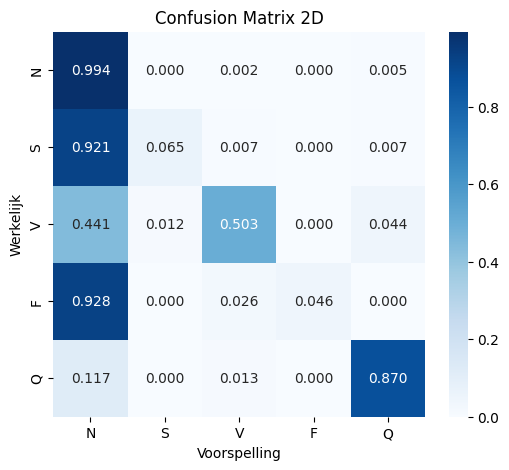


Recall per klasse
N: 0.994
S: 0.065
V: 0.503
F: 0.046
Q: 0.870


In [46]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, recall_score

model.eval()

y_true = []
y_pred = []

testdata = teststreamer.stream()

with torch.no_grad():
    for _ in range(len(teststreamer)):
        X, y = next(testdata)

        predictions = model(X).argmax(dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Confusion matrix
cfm = confusion_matrix(y_true, y_pred)

# Normaliseer per rij (diagonaal = recall)
cfm = cfm / cfm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))

sns.heatmap(
    cfm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=["N", "S", "V", "F", "Q"],
    yticklabels=["N", "S", "V", "F", "Q"],
)

plt.xlabel("Voorspelling")
plt.ylabel("Werkelijk")
plt.title("Confusion Matrix 2D")
plt.show()

# Recall per klasse
classes = ["N", "S", "V", "F", "Q"]

recalls = recall_score(y_true, y_pred, average=None)

print("\nRecall per klasse")
for cls, recall in zip(classes, recalls):
    print(f"{cls}: {recall:.3f}")

In [47]:
classes = ["N", "S", "V", "F", "Q"]

recalls = recall_score(
    y_true,
    y_pred,
    average=None,
)

print("\nRecall per klasse")

for class_name, recall_value in zip(classes, recalls):
    print(f"{class_name}: {recall_value:.3f}")


Recall per klasse
N: 0.994
S: 0.065
V: 0.503
F: 0.046
Q: 0.870


In [48]:
# ============================================
# Experiment 2 - 1D CNN met class weights
# ============================================

In [49]:
class_counts = torch.bincount(traindataset.y)

class_weights = class_counts.sum() / (
    len(class_counts) * class_counts.float()
)

print(class_weights)

tensor([ 0.2416,  7.8771,  3.0254, 27.3179,  2.7229])


In [50]:
loss_fn = nn.CrossEntropyLoss(
    weight=class_weights
)

In [51]:
classes = ["N", "S", "V", "F", "Q"]

for cls, count, weight in zip(classes, class_counts, class_weights):
    print(f"{cls}: count={count}, weight={weight:.3f}")

N: count=72471, weight=0.242
S: count=2223, weight=7.877
V: count=5788, weight=3.025
F: count=641, weight=27.318
Q: count=6431, weight=2.723


In [52]:
accuracy_metric = metrics.Accuracy()
f1micro_metric = metrics.F1Score(average="micro")
f1macro_metric = metrics.F1Score(average="macro")
precision_metric = metrics.Precision("micro")
recall_metric = metrics.Recall("macro")

In [53]:
from mltrainer import ReportTypes, Trainer, TrainerSettings
import torch.optim as optim

model = CNN2D(
    num_classes=5,
    filters=16,
    matrixshape=(16, 12),
)

loss_fn = nn.CrossEntropyLoss(
    weight=class_weights,
)

optimizer = torch.optim.Adam

train_steps = len(trainstreamer) // 5
valid_steps = len(teststreamer) // 5

settings = TrainerSettings(
    epochs=3,
    metrics=[
        accuracy_metric,
        f1micro_metric,
        f1macro_metric,
        precision_metric,
        recall_metric,
    ],
    logdir="logs/weighted_2d",
    train_steps=train_steps,
    valid_steps=valid_steps,
    reporttypes=[ReportTypes.TENSORBOARD],
    earlystop_kwargs=None,
)

trainer = Trainer(
    model=model,
    settings=settings,
    loss_fn=loss_fn,
    optimizer=optimizer,
    traindataloader=trainstreamer.stream(),
    validdataloader=teststreamer.stream(),
    scheduler=optim.lr_scheduler.ReduceLROnPlateau,
)

trainer.loop()

2026-07-15 12:26:28.067 | INFO     | mltrainer.settings:check_path:60 - Created logdir /home/azureuser/MADS-ML-EXAM-ML/notebooks/logs/weighted_2d
2026-07-15 12:26:28.068 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/weighted_2d/20260715-122628
100%|██████████| 547/547 [00:02<00:00, 261.93it/s]
2026-07-15 12:26:31.728 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 1.0437 test 0.8227 metric ['0.7284', '0.7284', '0.4848', '0.7284', '0.7247']
100%|██████████| 547/547 [00:01<00:00, 274.64it/s]
2026-07-15 12:26:35.494 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.7362 test 0.7378 metric ['0.5813', '0.5813', '0.4248', '0.5813', '0.7287']
100%|██████████| 547/547 [00:01<00:00, 277.41it/s]
2026-07-15 12:26:39.013 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.6711 test 0.6268 metric ['0.8120', '0.8120', '0.5388', '0.8120', '0.7838']
100%|██████████| 3/3 [00:10<00:00,  3.65s/it]


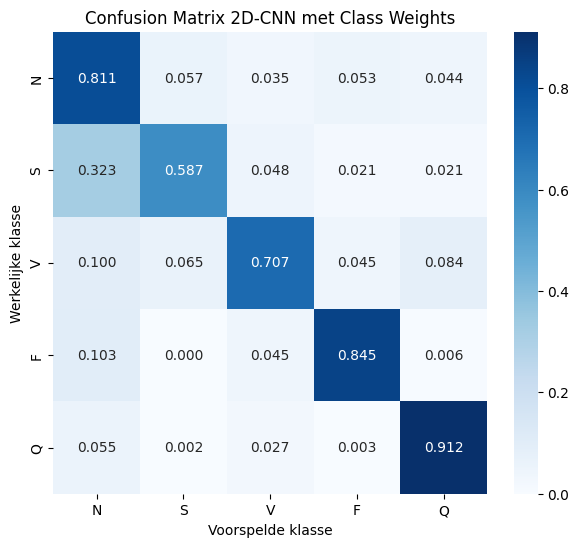


Recall per klasse:
N: 0.811
S: 0.587
V: 0.707
F: 0.845
Q: 0.912


In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import confusion_matrix, recall_score

# evaluatie
model.eval()

y_true = []
y_pred = []

testdata = teststreamer.stream()

with torch.no_grad():
    for _ in range(len(teststreamer)):
        X, y = next(testdata)

        output = model(X)
        predictions = output.argmax(dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(predictions.numpy())

# Confusion matrix berekenen
cfm = confusion_matrix(y_true, y_pred)

# Normaliseren per werkelijke klasse
cfm = cfm.astype(float) / cfm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cfm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=["N", "S", "V", "F", "Q"],
    yticklabels=["N", "S", "V", "F", "Q"],
)

plt.xlabel("Voorspelde klasse")
plt.ylabel("Werkelijke klasse")
plt.title("Confusion Matrix 2D-CNN met Class Weights")

plt.show()

# Recall per klasse
classes = ["N", "S", "V", "F", "Q"]

recalls = recall_score(
    y_true,
    y_pred,
    average=None,
)

print("\nRecall per klasse:")

for cls, r in zip(classes, recalls):
    print(f"{cls}: {r:.3f}")

In [58]:
# =============================================================
# Experiment 3 - 1D CNN met class weights en paralelle kernels
# =============================================================

In [62]:
import torch
from torch import nn


class ParallelCNN2D(nn.Module):
    def __init__(
        self,
        num_classes: int = 5,
        filters: int = 16,
        matrixshape: tuple = (16, 12),
    ):
        super().__init__()

        # kleine kernel voor lokale patronen
        self.conv_small = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=filters,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        # Rgrotere kernel voor grote patronen
        self.conv_large = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=filters,
                kernel_size=5,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        pooled_height = matrixshape[0] // 2
        pooled_width = matrixshape[1] // 2

        # Twee routes worden samengevoegd
        flatten_size = (
            2
            * filters
            * pooled_height
            * pooled_width
        )

        self.dense = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_small = self.conv_small(x)
        x_large = self.conv_large(x)

        # Samenvoegen over de filterdimensie
        x = torch.cat(
            (x_small, x_large),
            dim=1,
        )

        logits = self.dense(x)

        return logits

In [72]:
parallel_model = ParallelCNN2D(
    num_classes=5,
    filters=16,
    matrixshape=(16, 12),
)

x, y = next(trainstreamer.stream())

parallel_model.eval()

with torch.no_grad():
    output = parallel_model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)
print("Target shape:", y.shape)

Input shape: torch.Size([32, 1, 16, 12])
Output shape: torch.Size([32, 5])
Target shape: torch.Size([32])


In [75]:
from mltrainer import ReportTypes, Trainer, TrainerSettings
import torch.optim as optim

parallel_model = ParallelCNN2D(
    num_classes=5,
    filters=16,
    matrixshape=(16, 12),
)

loss_fn = nn.CrossEntropyLoss(
    weight=class_weights,
)

optimizer = torch.optim.Adam

train_steps = len(trainstreamer) // 5
valid_steps = len(teststreamer) // 5

settings = TrainerSettings(
    epochs=3,
    metrics=[
        accuracy_metric,
        f1micro_metric,
        f1macro_metric,
        precision_metric,
        recall_metric,
    ],
    logdir="logs/parallel_2d",
    train_steps=train_steps,
    valid_steps=valid_steps,
    reporttypes=[ReportTypes.TENSORBOARD],
    earlystop_kwargs=None,
)

trainer = Trainer(
    model=parallel_model,
    settings=settings,
    loss_fn=loss_fn,
    optimizer=optimizer,
    traindataloader=trainstreamer.stream(),
    validdataloader=teststreamer.stream(),
    scheduler=optim.lr_scheduler.ReduceLROnPlateau,
)

trainer.loop()

2026-07-15 13:36:21.774 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to logs/parallel_2d/20260715-133621
100%|██████████| 547/547 [00:03<00:00, 156.61it/s]
2026-07-15 13:36:26.927 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.9495 test 0.7407 metric ['0.8821', '0.8821', '0.6001', '0.8821', '0.7797']
100%|██████████| 547/547 [00:03<00:00, 157.70it/s]
2026-07-15 13:36:32.086 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.6793 test 0.5781 metric ['0.7943', '0.7943', '0.5468', '0.7943', '0.7997']
100%|██████████| 547/547 [00:03<00:00, 150.82it/s]
2026-07-15 13:36:37.384 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.5539 test 0.6037 metric ['0.8497', '0.8497', '0.5899', '0.8497', '0.7974']
100%|██████████| 3/3 [00:15<00:00,  5.20s/it]


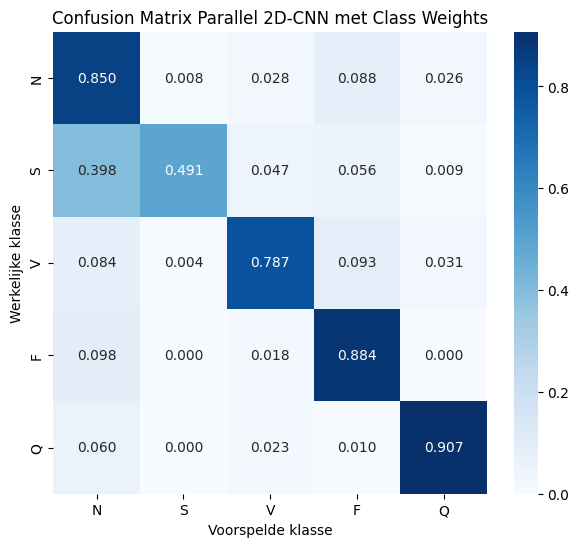


Recall per klasse:
N: 0.850
S: 0.491
V: 0.787
F: 0.884
Q: 0.907


In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import confusion_matrix, recall_score

model = parallel_model

# evaluatie
model.eval()

y_true = []
y_pred = []

testdata = teststreamer.stream()

with torch.no_grad():
    for _ in range(len(teststreamer)):
        X, y = next(testdata)

        output = model(X)
        predictions = output.argmax(dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(predictions.numpy())

# Confusion matrix berekenen
cfm = confusion_matrix(y_true, y_pred)

# Normaliseren per werkelijke klasse
cfm = cfm.astype(float) / cfm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cfm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=["N", "S", "V", "F", "Q"],
    yticklabels=["N", "S", "V", "F", "Q"],
)

plt.xlabel("Voorspelde klasse")
plt.ylabel("Werkelijke klasse")
plt.title("Confusion Matrix Parallel 2D-CNN met Class Weights")

plt.show()

# Recall per klasse
classes = ["N", "S", "V", "F", "Q"]

recalls = recall_score(
    y_true,
    y_pred,
    average=None,
)

print("\nRecall per klasse:")

for cls, r in zip(classes, recalls):
    print(f"{cls}: {r:.3f}")